In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import pdist, squareform

from sklearn.cluster import OPTICS

# Data
data = "data/output/02_data_understanding/clean_data_train.csv"

# Load data
df = pd.read_csv(data)
df.describe()

# theme of plots 'viridis'

,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,numRegions,userReviewsTotal,totalRecognitions,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
count,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,...,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000
mean,7.115757,1990.937029,55.383346,246.218891,51.289249,1.672094,2.711038,2.916661,2.922972,0.596930,...,0.000072,0.001291,0.000789,0.000072,0.014990,0.003658,0.000359,0.002725,0.000072,0.000072
std,1.397509,26.489942,33.982376,884.273132,68.327586,6.534696,2.683848,4.325575,10.489713,2.365819,...,0.008469,0.035908,0.028078,0.008469,0.121515,0.060371,0.018934,0.052136,0.008469,0.008469
min,1.000000,1878.000000,0.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1976.000000,30.000000,15.000000,16.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,1996.000000,50.000000,34.000000,34.000000,0.000000,2.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,2012.000000,90.000000,126.000000,62.000000,1.000000,3.000000,3.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,2024.000000,176.000000,14906.000000,1885.000000,122.000000,8.000000,45.000000,296.000000,49.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
scaler = MinMaxScaler()

# Supponiamo che df_Z sia il tuo DataFrame con le feature numeriche
numCol = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

# Normalizza i dati
df_Z = scaler.fit_transform(df[numCol])

# Reachability plot

In [23]:
optics = OPTICS(min_samples=10, xi=.1)
optics.fit(df_Z)

OPTICS(min_cluster_size=0.05, min_samples=10, xi=0.1)

Text(0.5, 1.0, 'Reachability Plot')

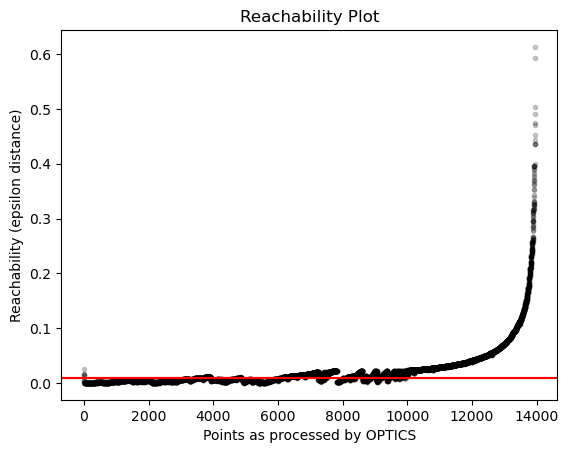

In [ ]:
# Valleys in the plot correspond to the clusters
space = np.arange(len(df_Z))
reachability = optics.reachability_[optics.ordering_]
labels = optics.labels_[optics.ordering_]

# Reachability plot
plt.plot(space, reachability, "k.", alpha=0.1)
plt.xlabel("Points as processed by OPTICS")
plt.ylabel("Reachability (epsilon distance)")
plt.axhline(0.01, c="red")
plt.title("Reachability Plot")


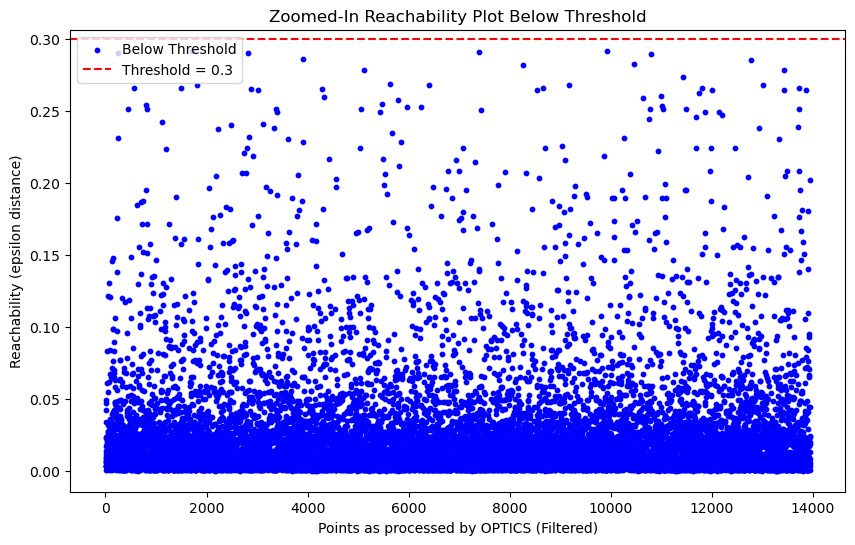

In [63]:
threshold = 0.3
# Filtered data
filtered_space = space[reachability < threshold]
filtered_reachability = reachability[reachability < threshold]

# Filtered plot with zoom-in
plt.figure(figsize=(10, 6))
plt.scatter(filtered_space, filtered_reachability, c="blue", s=10, label="Below Threshold")
plt.axhline(threshold, c="red", linestyle="--", label=f"Threshold = {threshold}")
plt.xlabel("Points as processed by OPTICS (Filtered)")
plt.ylabel("Reachability (epsilon distance)")
plt.title("Zoomed-In Reachability Plot Below Threshold")
plt.legend()
plt.show()

In [78]:
# Instantiate OPTICS with desired parameters
optics = OPTICS(eps=0.1, min_samples=5, metric='euclidean', xi = 0.2)

# Fit the model to your dataset (replace `X` with your data)
optics.fit(df_Z)

# Extract clustering results
labels = optics.labels_               # Cluster labels (-1 indicates noise points)
reachability = optics.reachability_   # Reachability distances
ordering = optics.ordering_           # The order in which points are processed


In [79]:
print(np.unique(optics.labels_))
# number of outliers
print(np.sum(optics.labels_ == -1))

[ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224]
12186


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

def load_labels_from_txt(txt_path):
    """
    Carica le etichette da un file di testo.

    Args:
        txt_path (str): Il percorso del file di testo.

    Returns:
        dict: Un dizionario con le etichette mappate.
    """
    labels = {}
    with open(txt_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(': ')
            labels[int(value)] = key
    return labels

def plot_optics_clusters(df, y_mapped, txt_path="./encoding_lists/titleType.txt", min_samples=5, xi=0.05, remove_column=None):
    """
    Esegue il clustering OPTICS e traccia i centri dei cluster.

    Parameters:
    df (DataFrame): Il DataFrame contenente i dati.
    y_mapped (Series): Serie contenente le etichette mappate.
    txt_path (str): Il percorso del file di testo contenente le etichette.
    min_samples (int): Numero minimo di campioni per formare un cluster.
    xi (float): Parametro di densità minima per formare un cluster.
    remove_column (str): Nome della colonna da rimuovere dal grafico.
    """
    # Carica le etichette dal file di testo
    labels_dict = load_labels_from_txt(txt_path)

    # Normalizza i dati
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df)
    
    # Calcola la matrice delle distanze
    distance_matrix = squareform(pdist(df_scaled, metric='euclidean'))
    
    # Esegui OPTICS
    optics = OPTICS(min_samples=min_samples, xi=xi, metric='precomputed')
    labels = optics.fit_predict(distance_matrix)
    
    # Aggiungi le etichette dei cluster al DataFrame
    df['optics_labels'] = labels
    
    # Calcola i centroidi dei cluster
    centers = []
    for label in np.unique(labels):
        if label != -1:  # Ignora il rumore
            centers.append(df_scaled[labels == label].mean(axis=0))
    centers = np.array(centers)
    centers = scaler.inverse_transform(centers)
    
    # Plot con tutte le colonne
    plt.figure(figsize=(10, 3))
    clust_name = [chr(65 + i) for i in range(len(centers))]  # Genera nomi di cluster A, B, C, ...
    
    for i in range(len(centers)):
        plt.plot(centers[i], marker='o', label=clust_name[i])
    
    plt.xticks(range(0, len(df.columns) - 1), df.columns[:-1], fontsize=13)
    plt.yticks(fontsize=13)
    plt.xticks(rotation=90)
    plt.legend(fontsize=13, loc='best')
    plt.grid(axis='y')
    plt.title(f'OPTICS Clustering (All Columns)')
    plt.show()
    
    # Plot senza la colonna specificata
    if remove_column and remove_column in df.columns:
        plt.figure(figsize=(10, 3))
        col_index = df.columns.get_loc(remove_column)
        columns_to_plot = df.columns.delete(col_index)
        
        for i in range(len(centers)):
            centers_to_plot = np.delete(centers[i], col_index)
            plt.plot(centers_to_plot, marker='o', label=clust_name[i])
        
        plt.xticks(range(0, len(columns_to_plot)), columns_to_plot, fontsize=13)
        plt.yticks(fontsize=13)
        plt.xticks(rotation=90)
        plt.legend(fontsize=13, loc='best')
        plt.grid(axis='y')
        plt.title(f'OPTICS Clustering (Without {remove_column})')
        plt.show()
    
    # Plot della distribuzione delle etichette di cluster
    bar_pl = y_mapped.groupby(df['optics_labels']).value_counts(normalize=True).unstack(1)
    bar_pl = bar_pl.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    bar_pl.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5)
    
    plt.xticks(range(0, len(clust_name)), clust_name, fontsize=13, rotation=0)
    plt.yticks(fontsize=13)
    plt.legend(bbox_to_anchor=(1, 1))
    plt.title('Distribution of Cluster Labels')
    plt.show()
    
    # Plot del numero di elementi in ciascun cluster raggruppati per y_mapped
    cluster_counts = df.groupby(['optics_labels', y_mapped]).size().unstack().fillna(0)
    cluster_counts = cluster_counts.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    cluster_counts.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5, figsize=(10, 6))
    
    plt.xticks(range(0, len(clust_name)), clust_name, fontsize=13, rotation=0)
    plt.yticks(fontsize=13)
    plt.xlabel('Cluster')
    plt.ylabel('Number of Elements')
    plt.title(f'Number of Elements in Each Cluster Grouped by {y_mapped.name}')
    plt.legend(title=y_mapped.name, bbox_to_anchor=(1, 1))
    plt.show()

# Esempio di utilizzo
# df = pd.read_csv("path/to/your/data.csv")  # Carica il tuo DataFrame
# y_mapped = ...  # Definisci la tua Serie contenente le etichette mappate
# txt_path = '/path/to/titleType.txt'  # Specifica il percorso del file di testo
# plot_optics_clusters(df, y_mapped, txt_path, min_samples=5, xi=0.05, remove_column='column_name')

In [ ]:
plot_optics_clusters(df[numCol], df['titleType'], txt_path="./encoding_lists/titleType.txt", min_samples=8, xi=0.2, remove_column='titleType')